# Fertility Health

## 1. Scope the project

My plan is to use a supervised learning technique to predict the fertility health focusing on various factors that are most likely to affect someone's fertility, using data from 2026 which include both male and female health indicators with lifestyle and treatment data.

## 2. Gather Data

Read the following file into Python:
- Fertility Health Data: *Fertility_Health_Data_2026.csv*

In [2]:
import pandas as pd

In [3]:
fertility = pd.read_csv("C:/Users/user/Downloads/Fertility_Health_Dataset_2026.csv")
fertility

,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome
0,1,26,35,22.6,Regular,No,High,No,NaN,75.7,74.1,13,NaN,Success
1,2,39,30,28.0,Regular,No,High,Yes,Moderate,25.2,27.4,35,NaN,Failure
2,3,34,35,24.1,Regular,Yes,Low,No,High,64.0,74.5,13,NaN,Success
3,4,30,22,19.6,Regular,No,High,No,High,87.3,31.9,31,NaN,Success
4,5,27,40,33.6,Irregular,No,Low,No,High,116.9,51.3,21,Medication,Success
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,29,39,28.4,Regular,No,High,No,Moderate,109.5,34.0,27,NaN,Success
796,797,29,26,19.1,Regular,Yes,Low,No,NaN,74.5,70.1,28,NaN,Success
797,798,38,33,26.8,Irregular,No,High,Yes,NaN,65.7,42.0,16,NaN,Success
798,799,36,33,20.6,Irregular,No,High,No,High,69.1,41.4,33,NaN,Failure


In [12]:
fertility.value_counts()

Couple_ID  Female_Age  Male_Age  BMI   Menstrual_Regularity  PCOS  Stress_Level  Smoking  Alcohol_Intake  Sperm_Count_Million_per_ml  Motility_%  Trying_Duration_Months  Treatment_Type  Pregnancy_Outcome
5          27          40        33.6  Irregular             No    Low           No       High            116.9                       51.3        21                      Medication      Success              1
550        42          28        19.8  Regular               No    Low           No       Moderate        33.0                        34.1        2                       Medication      Failure              1
507        41          47        24.5  Regular               Yes   Medium        No       Moderate        39.4                        77.8        17                      Medication      Success              1
510        21          23        26.1  Regular               No    High          No       High            108.3                       84.8        15                     

## 3. Clean Data

### a. Check Data Types

In [4]:
fertility.dtypes

Couple_ID                       int64
Female_Age                      int64
Male_Age                        int64
BMI                           float64
Menstrual_Regularity           object
PCOS                           object
Stress_Level                   object
Smoking                        object
Alcohol_Intake                 object
Sperm_Count_Million_per_ml    float64
Motility_%                    float64
Trying_Duration_Months          int64
Treatment_Type                 object
Pregnancy_Outcome              object
dtype: object

In [5]:
fertility['Menstrual_Regularity']

0        Regular
1        Regular
2        Regular
3        Regular
4      Irregular
         ...    
795      Regular
796      Regular
797    Irregular
798    Irregular
799    Irregular
Name: Menstrual_Regularity, Length: 800, dtype: object

In [6]:
fertility['PCOS']

0       No
1       No
2      Yes
3       No
4       No
      ... 
795     No
796    Yes
797     No
798     No
799     No
Name: PCOS, Length: 800, dtype: object

In [7]:
fertility['Treatment_Type']

0             NaN
1             NaN
2             NaN
3             NaN
4      Medication
          ...    
795           NaN
796           NaN
797           NaN
798           NaN
799           NaN
Name: Treatment_Type, Length: 800, dtype: object

### b. Resolve Data Issues

#### i. Missing data

In [8]:
fertility.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Couple_ID                   800 non-null    int64  
 1   Female_Age                  800 non-null    int64  
 2   Male_Age                    800 non-null    int64  
 3   BMI                         800 non-null    float64
 4   Menstrual_Regularity        800 non-null    object 
 5   PCOS                        800 non-null    object 
 6   Stress_Level                800 non-null    object 
 7   Smoking                     800 non-null    object 
 8   Alcohol_Intake              541 non-null    object 
 9   Sperm_Count_Million_per_ml  800 non-null    float64
 10  Motility_%                  800 non-null    float64
 11  Trying_Duration_Months      800 non-null    int64  
 12  Treatment_Type              300 non-null    object 
 13  Pregnancy_Outcome           800 non

In [9]:
#There are NaN values in Alcohol_Intake and Treatment_Type
fertility.head()

,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome
0,1,26,35,22.6,Regular,No,High,No,NaN,75.7,74.1,13,NaN,Success
1,2,39,30,28.0,Regular,No,High,Yes,Moderate,25.2,27.4,35,NaN,Failure
2,3,34,35,24.1,Regular,Yes,Low,No,High,64.0,74.5,13,NaN,Success
3,4,30,22,19.6,Regular,No,High,No,High,87.3,31.9,31,NaN,Success
4,5,27,40,33.6,Irregular,No,Low,No,High,116.9,51.3,21,Medication,Success


In [10]:
fertility[fertility['Alcohol_Intake'].isna()]

,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome
0,1,26,35,22.6,Regular,No,High,No,NaN,75.7,74.1,13,NaN,Success
5,6,40,34,20.3,Regular,No,Medium,No,NaN,28.2,34.7,32,NaN,Failure
7,8,38,25,25.6,Regular,Yes,Medium,No,NaN,13.7,81.4,8,NaN,Failure
15,16,43,47,32.4,Regular,No,Low,No,NaN,34.3,54.8,10,NaN,Success
16,17,22,47,22.2,Regular,No,High,No,NaN,45.5,39.3,11,NaN,Success
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
791,792,42,46,28.8,Regular,No,High,Yes,NaN,72.6,35.8,33,NaN,Failure
792,793,24,28,29.2,Regular,Yes,Medium,No,NaN,112.5,81.1,10,Medication,Success
794,795,24,24,28.8,Regular,No,Low,No,NaN,110.5,36.4,4,NaN,Success
796,797,29,26,19.1,Regular,Yes,Low,No,NaN,74.5,70.1,28,NaN,Success


In [13]:
fertility.describe()

,Couple_ID,Female_Age,Male_Age,BMI,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months
count,800.0000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,400.5000,31.907500,35.255000,26.647000,61.072000,54.955000,18.308750
std,231.0844,7.461806,8.216865,4.996724,34.207898,19.767997,9.958156
min,1.0000,20.000000,22.000000,18.100000,5.100000,20.100000,1.000000
25%,200.7500,25.000000,28.000000,22.100000,30.600000,38.275000,10.000000
50%,400.5000,32.000000,35.000000,26.800000,61.050000,55.550000,18.000000
75%,600.2500,39.000000,43.000000,31.000000,90.825000,71.100000,27.000000
max,800.0000,44.000000,49.000000,35.000000,119.900000,90.000000,35.000000


In [15]:
fertility['Alcohol_Intake'].fillna(0, inplace=True)
fertility

,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome
0,1,26,35,22.6,Regular,No,High,No,0,75.7,74.1,13,NaN,Success
1,2,39,30,28.0,Regular,No,High,Yes,Moderate,25.2,27.4,35,NaN,Failure
2,3,34,35,24.1,Regular,Yes,Low,No,High,64.0,74.5,13,NaN,Success
3,4,30,22,19.6,Regular,No,High,No,High,87.3,31.9,31,NaN,Success
4,5,27,40,33.6,Irregular,No,Low,No,High,116.9,51.3,21,Medication,Success
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,29,39,28.4,Regular,No,High,No,Moderate,109.5,34.0,27,NaN,Success
796,797,29,26,19.1,Regular,Yes,Low,No,0,74.5,70.1,28,NaN,Success
797,798,38,33,26.8,Irregular,No,High,Yes,0,65.7,42.0,16,NaN,Success
798,799,36,33,20.6,Irregular,No,High,No,High,69.1,41.4,33,NaN,Failure


In [19]:
fertility['Treatment_Type'].fillna(0, inplace=True)
fertility

,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome
0,1,26,35,22.6,Regular,No,High,No,0,75.7,74.1,13,0,Success
1,2,39,30,28.0,Regular,No,High,Yes,Moderate,25.2,27.4,35,0,Failure
2,3,34,35,24.1,Regular,Yes,Low,No,High,64.0,74.5,13,0,Success
3,4,30,22,19.6,Regular,No,High,No,High,87.3,31.9,31,0,Success
4,5,27,40,33.6,Irregular,No,Low,No,High,116.9,51.3,21,Medication,Success
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,29,39,28.4,Regular,No,High,No,Moderate,109.5,34.0,27,0,Success
796,797,29,26,19.1,Regular,Yes,Low,No,0,74.5,70.1,28,0,Success
797,798,38,33,26.8,Irregular,No,High,Yes,0,65.7,42.0,16,0,Success
798,799,36,33,20.6,Irregular,No,High,No,High,69.1,41.4,33,0,Failure


#### ii. Inconsistent text & typos

In [23]:
#No inconsistencies or typos
fertility.describe()

,Couple_ID,Female_Age,Male_Age,BMI,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months
count,800.0000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,400.5000,31.907500,35.255000,26.647000,61.072000,54.955000,18.308750
std,231.0844,7.461806,8.216865,4.996724,34.207898,19.767997,9.958156
min,1.0000,20.000000,22.000000,18.100000,5.100000,20.100000,1.000000
25%,200.7500,25.000000,28.000000,22.100000,30.600000,38.275000,10.000000
50%,400.5000,32.000000,35.000000,26.800000,61.050000,55.550000,18.000000
75%,600.2500,39.000000,43.000000,31.000000,90.825000,71.100000,27.000000
max,800.0000,44.000000,49.000000,35.000000,119.900000,90.000000,35.000000


In [22]:
fertility['Trying_Duration_Months'].max()

35

In [36]:
fertility.Trying_Duration_Months

0      13
1      35
2      13
3      31
4      21
       ..
795    27
796    28
797    16
798    33
799    19
Name: Trying_Duration_Months, Length: 800, dtype: int64

#### iii. Duplicate rows

In [24]:
fertility[fertility.duplicated()]

,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome


#### iv. Outliers

In [25]:
fertility.describe()

,Couple_ID,Female_Age,Male_Age,BMI,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months
count,800.0000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,400.5000,31.907500,35.255000,26.647000,61.072000,54.955000,18.308750
std,231.0844,7.461806,8.216865,4.996724,34.207898,19.767997,9.958156
min,1.0000,20.000000,22.000000,18.100000,5.100000,20.100000,1.000000
25%,200.7500,25.000000,28.000000,22.100000,30.600000,38.275000,10.000000
50%,400.5000,32.000000,35.000000,26.800000,61.050000,55.550000,18.000000
75%,600.2500,39.000000,43.000000,31.000000,90.825000,71.100000,27.000000
max,800.0000,44.000000,49.000000,35.000000,119.900000,90.000000,35.000000


In [29]:
import seaborn as sns

C:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Sperm_Count_Million_per_ml', ylabel='Count'>

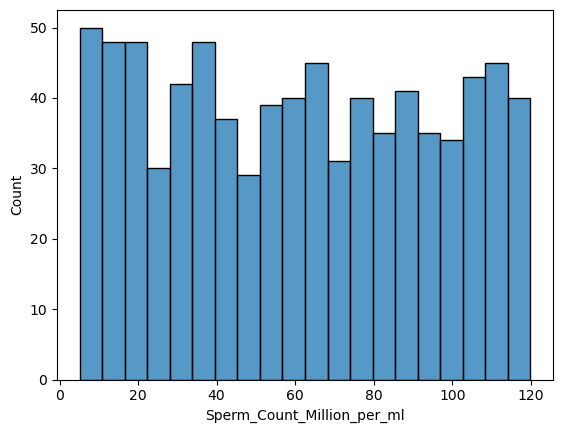

In [33]:
sns.histplot(fertility.Sperm_Count_Million_per_ml, bins=20)

<Axes: ylabel='Sperm_Count_Million_per_ml'>

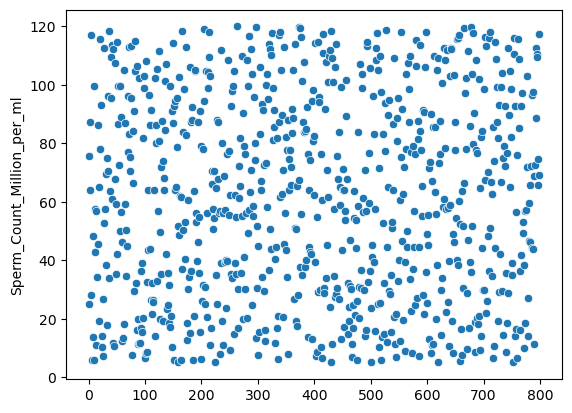

In [34]:
sns.scatterplot(fertility.Sperm_Count_Million_per_ml)

### c. Create new columns

Create two new columns that will be useful for EDA & Modeling:
- Duration: whether a couple's trying duration took long or short time
- Level of sperm motility: whether the level is low, normal or high based on the Motility %.

In [37]:
fertility.head(10)

,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome
0,1,26,35,22.6,Regular,No,High,No,0,75.7,74.1,13,0,Success
1,2,39,30,28.0,Regular,No,High,Yes,Moderate,25.2,27.4,35,0,Failure
2,3,34,35,24.1,Regular,Yes,Low,No,High,64.0,74.5,13,0,Success
3,4,30,22,19.6,Regular,No,High,No,High,87.3,31.9,31,0,Success
4,5,27,40,33.6,Irregular,No,Low,No,High,116.9,51.3,21,Medication,Success
5,6,40,34,20.3,Regular,No,Medium,No,0,28.2,34.7,32,0,Failure
6,7,26,34,34.2,Regular,No,Medium,No,Moderate,6.1,68.3,34,Medication,Success
7,8,38,25,25.6,Regular,Yes,Medium,No,0,13.7,81.4,8,0,Failure
8,9,42,22,21.1,Irregular,No,High,No,High,48.2,40.3,2,0,Failure
9,10,30,38,27.2,Irregular,Yes,Low,Yes,Moderate,99.4,25.7,32,0,Success


In [39]:
import numpy as np

In [41]:
fertility['Duration'] = np.where(fertility['Trying_Duration_Months']<=13, 'Short time', 'Long time')
fertility.head(10)

,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome,Duration
0,1,26,35,22.6,Regular,No,High,No,0,75.7,74.1,13,0,Success,Short time
1,2,39,30,28.0,Regular,No,High,Yes,Moderate,25.2,27.4,35,0,Failure,Long time
2,3,34,35,24.1,Regular,Yes,Low,No,High,64.0,74.5,13,0,Success,Short time
3,4,30,22,19.6,Regular,No,High,No,High,87.3,31.9,31,0,Success,Long time
4,5,27,40,33.6,Irregular,No,Low,No,High,116.9,51.3,21,Medication,Success,Long time
5,6,40,34,20.3,Regular,No,Medium,No,0,28.2,34.7,32,0,Failure,Long time
6,7,26,34,34.2,Regular,No,Medium,No,Moderate,6.1,68.3,34,Medication,Success,Long time
7,8,38,25,25.6,Regular,Yes,Medium,No,0,13.7,81.4,8,0,Failure,Short time
8,9,42,22,21.1,Irregular,No,High,No,High,48.2,40.3,2,0,Failure,Short time
9,10,30,38,27.2,Irregular,Yes,Low,Yes,Moderate,99.4,25.7,32,0,Success,Long time


In [42]:
fertility['Level of Sperm Motility'] = np.where(fertility['Motility_%']<40.0, 'Low',
                                       np.where(fertility['Motility_%'] <= 60, 'Normal', 'High'))
fertility.head(10)

,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome,Duration,Level of Sperm Motility
0,1,26,35,22.6,Regular,No,High,No,0,75.7,74.1,13,0,Success,Short time,High
1,2,39,30,28.0,Regular,No,High,Yes,Moderate,25.2,27.4,35,0,Failure,Long time,Low
2,3,34,35,24.1,Regular,Yes,Low,No,High,64.0,74.5,13,0,Success,Short time,High
3,4,30,22,19.6,Regular,No,High,No,High,87.3,31.9,31,0,Success,Long time,Low
4,5,27,40,33.6,Irregular,No,Low,No,High,116.9,51.3,21,Medication,Success,Long time,Normal
5,6,40,34,20.3,Regular,No,Medium,No,0,28.2,34.7,32,0,Failure,Long time,Low
6,7,26,34,34.2,Regular,No,Medium,No,Moderate,6.1,68.3,34,Medication,Success,Long time,High
7,8,38,25,25.6,Regular,Yes,Medium,No,0,13.7,81.4,8,0,Failure,Short time,High
8,9,42,22,21.1,Irregular,No,High,No,High,48.2,40.3,2,0,Failure,Short time,Normal
9,10,30,38,27.2,Irregular,Yes,Low,Yes,Moderate,99.4,25.7,32,0,Success,Long time,Low


## 4. EDA

Try to better understand the conditions under which a pregnancy outcome was successful, based on:
- PCOS, and
- Menstrual Regularity.

In [44]:
fertility.head(10)

,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome,Duration,Level of Sperm Motility
0,1,26,35,22.6,Regular,No,High,No,0,75.7,74.1,13,0,Success,Short time,High
1,2,39,30,28.0,Regular,No,High,Yes,Moderate,25.2,27.4,35,0,Failure,Long time,Low
2,3,34,35,24.1,Regular,Yes,Low,No,High,64.0,74.5,13,0,Success,Short time,High
3,4,30,22,19.6,Regular,No,High,No,High,87.3,31.9,31,0,Success,Long time,Low
4,5,27,40,33.6,Irregular,No,Low,No,High,116.9,51.3,21,Medication,Success,Long time,Normal
5,6,40,34,20.3,Regular,No,Medium,No,0,28.2,34.7,32,0,Failure,Long time,Low
6,7,26,34,34.2,Regular,No,Medium,No,Moderate,6.1,68.3,34,Medication,Success,Long time,High
7,8,38,25,25.6,Regular,Yes,Medium,No,0,13.7,81.4,8,0,Failure,Short time,High
8,9,42,22,21.1,Irregular,No,High,No,High,48.2,40.3,2,0,Failure,Short time,Normal
9,10,30,38,27.2,Irregular,Yes,Low,Yes,Moderate,99.4,25.7,32,0,Success,Long time,Low


In [49]:
mask = ((fertility.PCOS =='Yes') & (fertility.Menstrual_Regularity=='Irregular'))
filtered_fertility = fertility[mask]
filtered_fertility

,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome,Duration,Level of Sperm Motility
9,10,30,38,27.2,Irregular,Yes,Low,Yes,Moderate,99.4,25.7,32,0,Success,Long time,Low
19,20,21,43,34.8,Irregular,Yes,Medium,Yes,0,19.3,66.5,17,Medication,Success,Long time,High
23,24,21,33,33.7,Irregular,Yes,High,No,High,14.1,70.6,11,0,Success,Short time,High
41,42,24,28,20.0,Irregular,Yes,Medium,Yes,Moderate,61.1,71.4,22,0,Success,Long time,High
52,53,28,23,33.1,Irregular,Yes,Low,No,Moderate,99.7,27.7,35,IVF,Success,Long time,Low
61,62,22,31,31.6,Irregular,Yes,High,No,Moderate,13.5,34.0,4,0,Failure,Short time,Low
81,82,34,32,18.3,Irregular,Yes,Medium,No,High,29.5,67.1,13,Medication,Failure,Short time,High
100,101,44,24,28.3,Irregular,Yes,Low,Yes,High,6.6,41.2,20,0,Failure,Long time,Normal
110,111,36,31,33.0,Irregular,Yes,High,No,Moderate,26.6,70.6,23,IVF,Failure,Long time,High
114,115,20,22,24.7,Irregular,Yes,Medium,No,0,26.3,47.3,15,Medication,Success,Long time,Normal


In [53]:
filtered_fertility.groupby('Female_Age')['Pregnancy_Outcome'].sum()

Female_Age
20           SuccessSuccessSuccess
21    SuccessSuccessSuccessSuccess
22           FailureSuccessSuccess
23                  SuccessSuccess
24                  SuccessSuccess
25                         Success
26                         Failure
27                         Success
28                         Success
30                  SuccessSuccess
31                  SuccessSuccess
32                         Success
34                         Failure
36           FailureFailureSuccess
37                         Failure
38                  FailureFailure
39                  SuccessSuccess
40                         Success
41           SuccessSuccessFailure
42           FailureFailureFailure
43           SuccessFailureSuccess
44           FailureFailureFailure
Name: Pregnancy_Outcome, dtype: object

### 5. Prep for Modeling

Create a DataFrame that's ready for modeling with each row representing a couple (Female & Male) and numeric, non-null values.

In [56]:
fertility.head()

,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome,Duration,Level of Sperm Motility
0,1,26,35,22.6,Regular,No,High,No,0,75.7,74.1,13,0,Success,Short time,High
1,2,39,30,28.0,Regular,No,High,Yes,Moderate,25.2,27.4,35,0,Failure,Long time,Low
2,3,34,35,24.1,Regular,Yes,Low,No,High,64.0,74.5,13,0,Success,Short time,High
3,4,30,22,19.6,Regular,No,High,No,High,87.3,31.9,31,0,Success,Long time,Low
4,5,27,40,33.6,Irregular,No,Low,No,High,116.9,51.3,21,Medication,Success,Long time,Normal


In [70]:
fertility['Pregnancy_Outcome']= np.where(fertility['Pregnancy_Outcome']=='Success',1, 0)
fertility

,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome,Duration,Level of Sperm Motility
0,1,26,35,22.6,Regular,No,High,No,0,75.7,74.1,13,0,1,Short time,High
1,2,39,30,28.0,Regular,No,High,Yes,Moderate,25.2,27.4,35,0,0,Long time,Low
2,3,34,35,24.1,Regular,Yes,Low,No,High,64.0,74.5,13,0,1,Short time,High
3,4,30,22,19.6,Regular,No,High,No,High,87.3,31.9,31,0,1,Long time,Low
4,5,27,40,33.6,Irregular,No,Low,No,High,116.9,51.3,21,Medication,1,Long time,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,29,39,28.4,Regular,No,High,No,Moderate,109.5,34.0,27,0,1,Long time,Low
796,797,29,26,19.1,Regular,Yes,Low,No,0,74.5,70.1,28,0,1,Long time,High
797,798,38,33,26.8,Irregular,No,High,Yes,0,65.7,42.0,16,0,1,Long time,Normal
798,799,36,33,20.6,Irregular,No,High,No,High,69.1,41.4,33,0,0,Long time,Normal


In [71]:
fertility['PCOS']= np.where(fertility['PCOS']=='Yes',1, 0)
fertility

,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome,Duration,Level of Sperm Motility
0,1,26,35,22.6,Regular,0,High,No,0,75.7,74.1,13,0,1,Short time,High
1,2,39,30,28.0,Regular,0,High,Yes,Moderate,25.2,27.4,35,0,0,Long time,Low
2,3,34,35,24.1,Regular,1,Low,No,High,64.0,74.5,13,0,1,Short time,High
3,4,30,22,19.6,Regular,0,High,No,High,87.3,31.9,31,0,1,Long time,Low
4,5,27,40,33.6,Irregular,0,Low,No,High,116.9,51.3,21,Medication,1,Long time,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,29,39,28.4,Regular,0,High,No,Moderate,109.5,34.0,27,0,1,Long time,Low
796,797,29,26,19.1,Regular,1,Low,No,0,74.5,70.1,28,0,1,Long time,High
797,798,38,33,26.8,Irregular,0,High,Yes,0,65.7,42.0,16,0,1,Long time,Normal
798,799,36,33,20.6,Irregular,0,High,No,High,69.1,41.4,33,0,0,Long time,Normal


In [72]:
fertility['Menstrual_Regularity']= np.where(fertility['Menstrual_Regularity']=='Regular',1, 0)
fertility

,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome,Duration,Level of Sperm Motility
0,1,26,35,22.6,1,0,High,No,0,75.7,74.1,13,0,1,Short time,High
1,2,39,30,28.0,1,0,High,Yes,Moderate,25.2,27.4,35,0,0,Long time,Low
2,3,34,35,24.1,1,1,Low,No,High,64.0,74.5,13,0,1,Short time,High
3,4,30,22,19.6,1,0,High,No,High,87.3,31.9,31,0,1,Long time,Low
4,5,27,40,33.6,0,0,Low,No,High,116.9,51.3,21,Medication,1,Long time,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,29,39,28.4,1,0,High,No,Moderate,109.5,34.0,27,0,1,Long time,Low
796,797,29,26,19.1,1,1,Low,No,0,74.5,70.1,28,0,1,Long time,High
797,798,38,33,26.8,0,0,High,Yes,0,65.7,42.0,16,0,1,Long time,Normal
798,799,36,33,20.6,0,0,High,No,High,69.1,41.4,33,0,0,Long time,Normal


In [73]:
fertility['Smoking']= np.where(fertility['Smoking']=='Yes',1, 0)
fertility

,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome,Duration,Level of Sperm Motility
0,1,26,35,22.6,1,0,High,0,0,75.7,74.1,13,0,1,Short time,High
1,2,39,30,28.0,1,0,High,1,Moderate,25.2,27.4,35,0,0,Long time,Low
2,3,34,35,24.1,1,1,Low,0,High,64.0,74.5,13,0,1,Short time,High
3,4,30,22,19.6,1,0,High,0,High,87.3,31.9,31,0,1,Long time,Low
4,5,27,40,33.6,0,0,Low,0,High,116.9,51.3,21,Medication,1,Long time,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,29,39,28.4,1,0,High,0,Moderate,109.5,34.0,27,0,1,Long time,Low
796,797,29,26,19.1,1,1,Low,0,0,74.5,70.1,28,0,1,Long time,High
797,798,38,33,26.8,0,0,High,1,0,65.7,42.0,16,0,1,Long time,Normal
798,799,36,33,20.6,0,0,High,0,High,69.1,41.4,33,0,0,Long time,Normal


In [75]:
fertility['Female_Stress_Level'] = fertility['Stress_Level']
fertility

,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome,Duration,Level of Sperm Motility,Female_Stress_Level
0,1,26,35,22.6,1,0,1,0,0,75.7,74.1,13,0,1,Short time,High,1
1,2,39,30,28.0,1,0,1,1,Moderate,25.2,27.4,35,0,0,Long time,Low,1
2,3,34,35,24.1,1,1,0,0,High,64.0,74.5,13,0,1,Short time,High,0
3,4,30,22,19.6,1,0,1,0,High,87.3,31.9,31,0,1,Long time,Low,1
4,5,27,40,33.6,0,0,0,0,High,116.9,51.3,21,Medication,1,Long time,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,29,39,28.4,1,0,1,0,Moderate,109.5,34.0,27,0,1,Long time,Low,1
796,797,29,26,19.1,1,1,0,0,0,74.5,70.1,28,0,1,Long time,High,0
797,798,38,33,26.8,0,0,1,1,0,65.7,42.0,16,0,1,Long time,Normal,1
798,799,36,33,20.6,0,0,1,0,High,69.1,41.4,33,0,0,Long time,Normal,1


In [76]:
fertility['Stress_Level']= np.where(fertility['Stress_Level']=='High',1, 0)
fertility

,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome,Duration,Level of Sperm Motility,Female_Stress_Level
0,1,26,35,22.6,1,0,0,0,0,75.7,74.1,13,0,1,Short time,High,1
1,2,39,30,28.0,1,0,0,1,Moderate,25.2,27.4,35,0,0,Long time,Low,1
2,3,34,35,24.1,1,1,0,0,High,64.0,74.5,13,0,1,Short time,High,0
3,4,30,22,19.6,1,0,0,0,High,87.3,31.9,31,0,1,Long time,Low,1
4,5,27,40,33.6,0,0,0,0,High,116.9,51.3,21,Medication,1,Long time,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,29,39,28.4,1,0,0,0,Moderate,109.5,34.0,27,0,1,Long time,Low,1
796,797,29,26,19.1,1,1,0,0,0,74.5,70.1,28,0,1,Long time,High,0
797,798,38,33,26.8,0,0,0,1,0,65.7,42.0,16,0,1,Long time,Normal,1
798,799,36,33,20.6,0,0,0,0,High,69.1,41.4,33,0,0,Long time,Normal,1


In [87]:
fertility['Alcohol_Intake']= np.where(fertility['Alcohol_Intake']=='High',1, 0)
fertility

,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome,Duration,Level of Sperm Motility,Female_Stress_Level
0,1,26,35,22.6,1,0,0,0,0,75.7,74.1,13,0,1,Short time,High,1
1,2,39,30,28.0,1,0,0,1,0,25.2,27.4,35,0,0,Long time,Low,1
2,3,34,35,24.1,1,1,0,0,1,64.0,74.5,13,0,1,Short time,High,0
3,4,30,22,19.6,1,0,0,0,1,87.3,31.9,31,0,1,Long time,Low,1
4,5,27,40,33.6,0,0,0,0,1,116.9,51.3,21,Medication,1,Long time,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,29,39,28.4,1,0,0,0,0,109.5,34.0,27,0,1,Long time,Low,1
796,797,29,26,19.1,1,1,0,0,0,74.5,70.1,28,0,1,Long time,High,0
797,798,38,33,26.8,0,0,0,1,0,65.7,42.0,16,0,1,Long time,Normal,1
798,799,36,33,20.6,0,0,0,0,1,69.1,41.4,33,0,0,Long time,Normal,1


In [88]:
male_df = fertility[['Male_Age', 'BMI', 'Motility_%', 'Sperm_Count_Million_per_ml', 'Pregnancy_Outcome']]
male_df

,Male_Age,BMI,Motility_%,Sperm_Count_Million_per_ml,Pregnancy_Outcome
0,35,22.6,74.1,75.7,1
1,30,28.0,27.4,25.2,0
2,35,24.1,74.5,64.0,1
3,22,19.6,31.9,87.3,1
4,40,33.6,51.3,116.9,1
...,...,...,...,...,...
795,39,28.4,34.0,109.5,1
796,26,19.1,70.1,74.5,1
797,33,26.8,42.0,65.7,1
798,33,20.6,41.4,69.1,0


In [58]:
import seaborn as sns

In [94]:
female_df = fertility[['Female_Age', 'Menstrual_Regularity', 'PCOS', 'Female_Stress_Level','Trying_Duration_Months','Pregnancy_Outcome']]
female_df

,Female_Age,Menstrual_Regularity,PCOS,Female_Stress_Level,Trying_Duration_Months,Pregnancy_Outcome
0,26,1,0,1,13,1
1,39,1,0,1,35,0
2,34,1,1,0,13,1
3,30,1,0,1,31,1
4,27,0,0,0,21,1
...,...,...,...,...,...,...
795,29,1,0,1,27,1
796,29,1,1,0,28,1
797,38,0,0,1,16,1
798,36,0,0,1,33,0


In [81]:
male_df.corr()

,Male_Age,BMI,Motility_%,Sperm_Count_Million_per_ml,Pregnancy_Outcome
Male_Age,1.000000,0.037419,-0.053024,-0.030686,0.037467
BMI,0.037419,1.000000,-0.007895,-0.042718,-0.047424
Motility_%,-0.053024,-0.007895,1.000000,-0.038398,0.262131
Sperm_Count_Million_per_ml,-0.030686,-0.042718,-0.038398,1.000000,0.202675
Pregnancy_Outcome,0.037467,-0.047424,0.262131,0.202675,1.000000


In [96]:
female_df.corr()

,Female_Age,Menstrual_Regularity,PCOS,Female_Stress_Level,Trying_Duration_Months,Pregnancy_Outcome
Female_Age,1.000000,0.012315,0.019635,0.009952,-0.029563,-0.464258
Menstrual_Regularity,0.012315,1.000000,0.015752,0.012265,-0.027812,-0.028591
PCOS,0.019635,0.015752,1.000000,-0.066508,-0.015330,-0.107569
Female_Stress_Level,0.009952,0.012265,-0.066508,1.000000,0.035825,-0.099964
Trying_Duration_Months,-0.029563,-0.027812,-0.015330,0.035825,1.000000,0.027733
Pregnancy_Outcome,-0.464258,-0.028591,-0.107569,-0.099964,0.027733,1.000000


C:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating ins

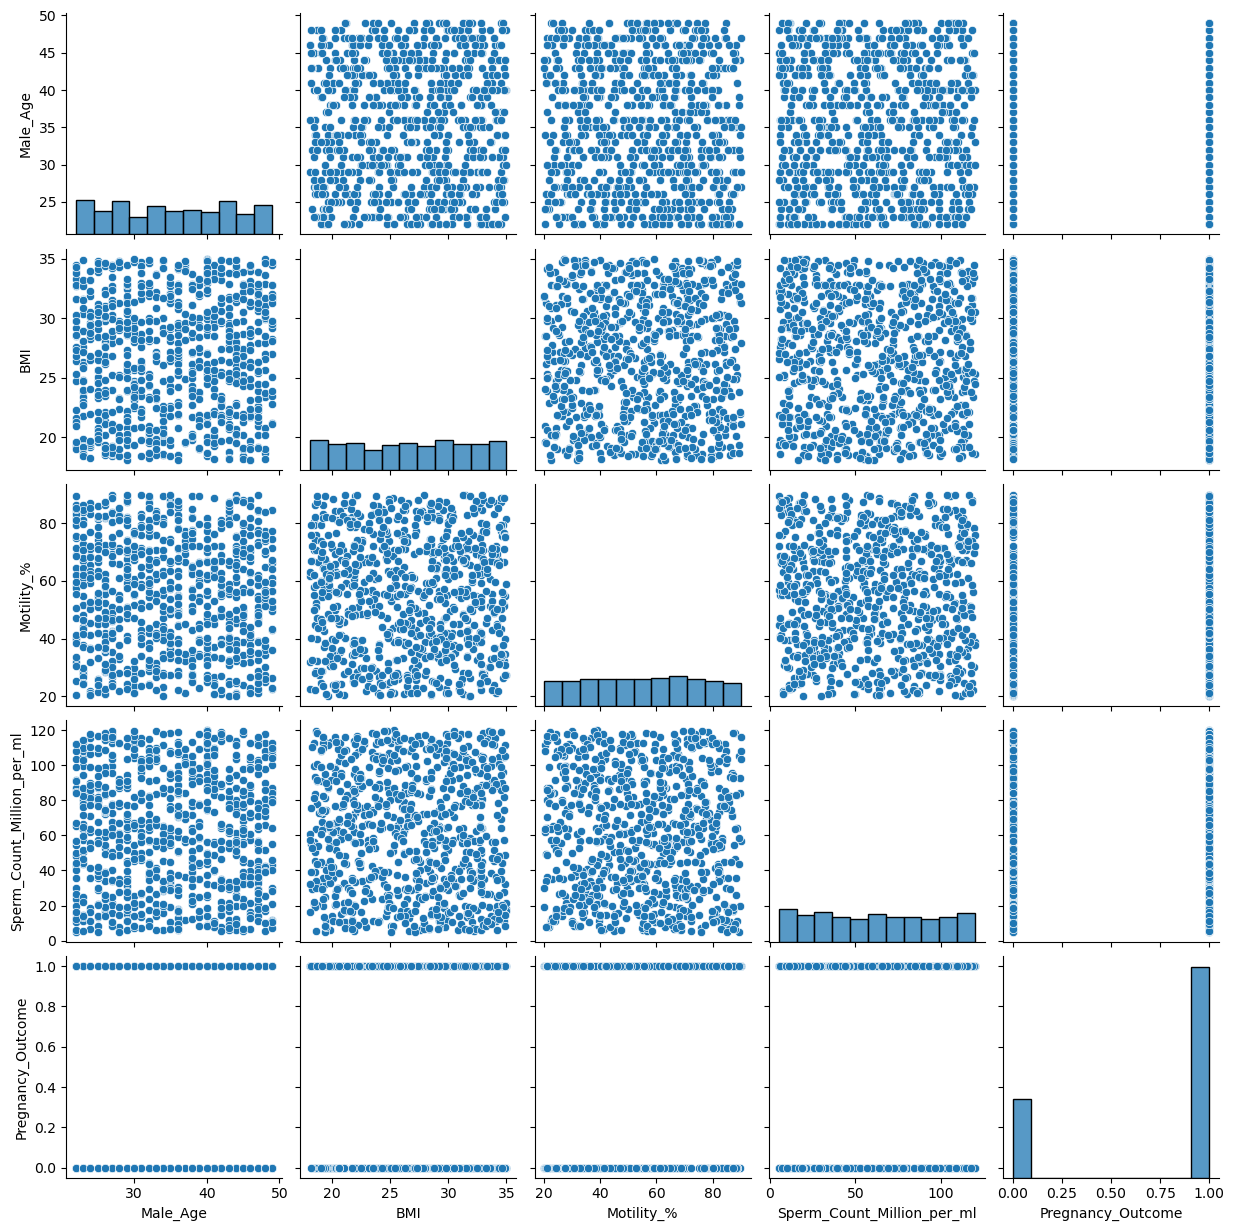

In [83]:
sns.pairplot(male_df)

C:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating ins

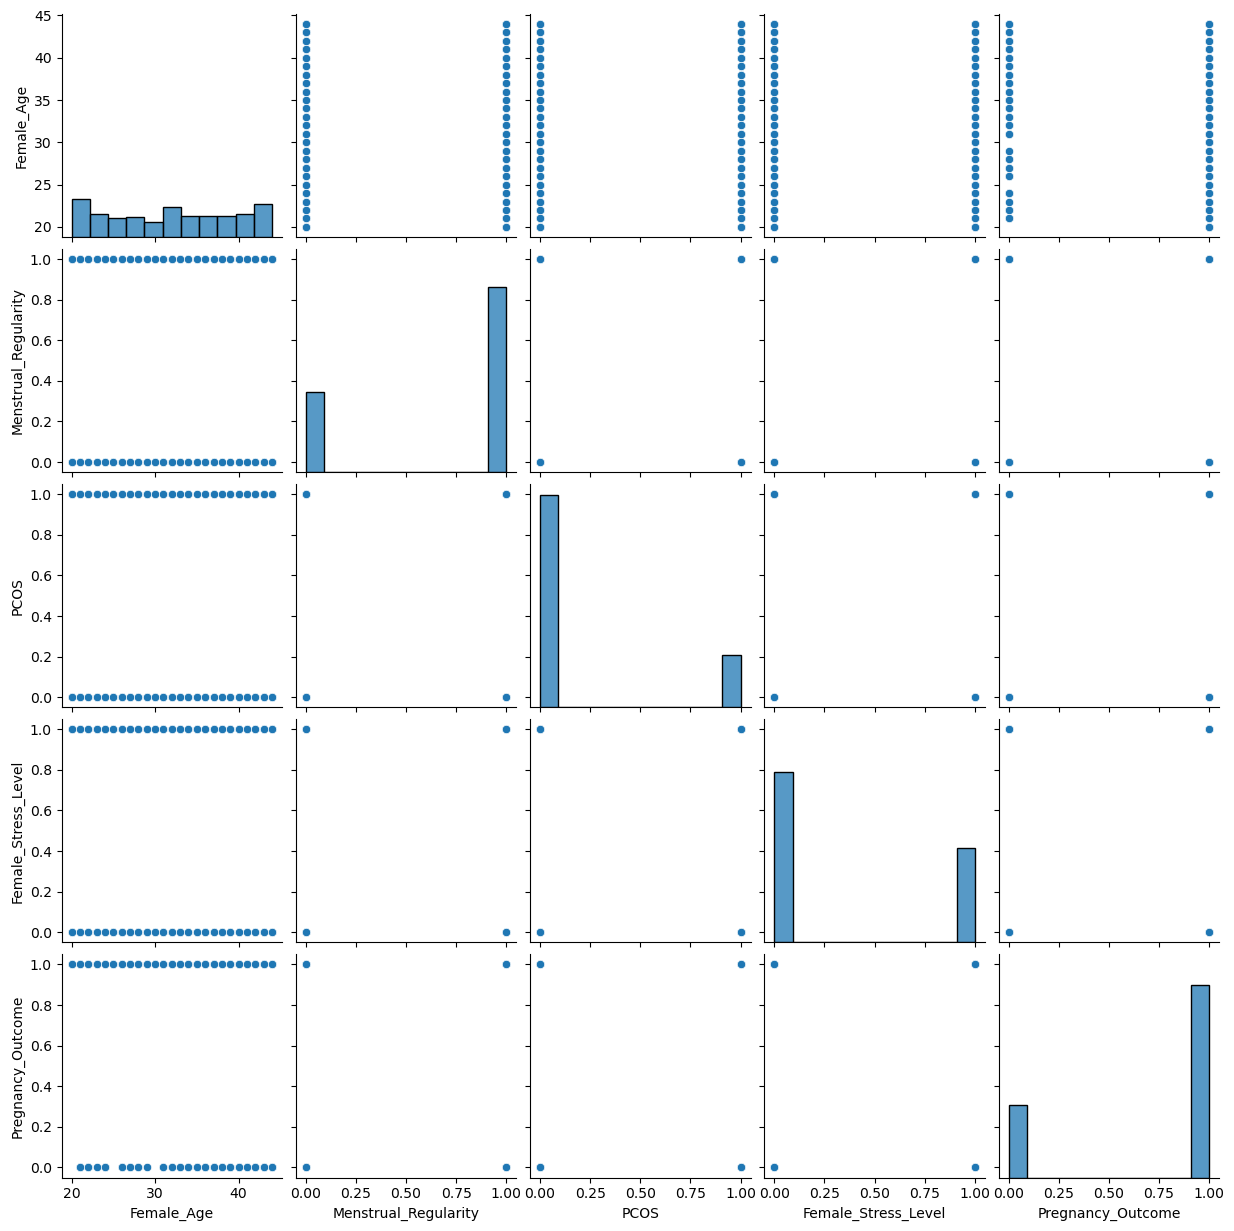

In [84]:
sns.pairplot(female_df);

In [90]:
fertility

,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome,Duration,Level of Sperm Motility,Female_Stress_Level
0,1,26,35,22.6,1,0,0,0,0,75.7,74.1,13,0,1,Short time,High,1
1,2,39,30,28.0,1,0,0,1,0,25.2,27.4,35,0,0,Long time,Low,1
2,3,34,35,24.1,1,1,0,0,1,64.0,74.5,13,0,1,Short time,High,0
3,4,30,22,19.6,1,0,0,0,1,87.3,31.9,31,0,1,Long time,Low,1
4,5,27,40,33.6,0,0,0,0,1,116.9,51.3,21,Medication,1,Long time,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,29,39,28.4,1,0,0,0,0,109.5,34.0,27,0,1,Long time,Low,1
796,797,29,26,19.1,1,1,0,0,0,74.5,70.1,28,0,1,Long time,High,0
797,798,38,33,26.8,0,0,0,1,0,65.7,42.0,16,0,1,Long time,Normal,1
798,799,36,33,20.6,0,0,0,0,1,69.1,41.4,33,0,0,Long time,Normal,1


In [93]:
male_lifestyle_df = fertility[['Male_Age','Smoking', 'Alcohol_Intake','Pregnancy_Outcome']]
male_lifestyle_df.corr()

,Male_Age,Smoking,Alcohol_Intake,Pregnancy_Outcome
Male_Age,1.000000,-0.064447,-0.026192,0.037467
Smoking,-0.064447,1.000000,-0.007536,-0.060839
Alcohol_Intake,-0.026192,-0.007536,1.000000,0.027379
Pregnancy_Outcome,0.037467,-0.060839,0.027379,1.000000


In [97]:
male_df.corr()

,Male_Age,BMI,Motility_%,Sperm_Count_Million_per_ml,Pregnancy_Outcome
Male_Age,1.000000,0.037419,-0.053024,-0.030686,0.037467
BMI,0.037419,1.000000,-0.007895,-0.042718,-0.047424
Motility_%,-0.053024,-0.007895,1.000000,-0.038398,0.262131
Sperm_Count_Million_per_ml,-0.030686,-0.042718,-0.038398,1.000000,0.202675
Pregnancy_Outcome,0.037467,-0.047424,0.262131,0.202675,1.000000


In [98]:
female_df.corr()

,Female_Age,Menstrual_Regularity,PCOS,Female_Stress_Level,Trying_Duration_Months,Pregnancy_Outcome
Female_Age,1.000000,0.012315,0.019635,0.009952,-0.029563,-0.464258
Menstrual_Regularity,0.012315,1.000000,0.015752,0.012265,-0.027812,-0.028591
PCOS,0.019635,0.015752,1.000000,-0.066508,-0.015330,-0.107569
Female_Stress_Level,0.009952,0.012265,-0.066508,1.000000,0.035825,-0.099964
Trying_Duration_Months,-0.029563,-0.027812,-0.015330,0.035825,1.000000,0.027733
Pregnancy_Outcome,-0.464258,-0.028591,-0.107569,-0.099964,0.027733,1.000000


### Comments based on correlations

#### a. Female Health Indicators and Pregnancy Outcome

- The PCOS seem to be related to less successful pregnancy outcomes.
- The more older a woman is, the less time it takes to try which is related to less successful pregnancy outcomes.
- The more female stress level, the less successful a pregnancy outcome is.


#### b.  Male Health Indicators and Pregnancy Outcome

- The older a man is, the more successful a pregnancy outcome might be.
- The more BMI for a man, the less successful a pregnancy outcome.
- Higher percentage of sperm motility is correlated to more successful pregnancy outcome. 
- The same goes for sperm count million per ml.

#### c. Male Lifestyle Indicators and Pregnancy Outcome

- The more male smoking, the less successful a pregnancy outcome